Iteration 0, Error: 155.38696
Iteration 100, Error: 6.37175
Iteration 200, Error: 1.83037
Iteration 300, Error: 0.67465
Iteration 400, Error: 0.09328
Iteration 500, Error: 0.01431
Iteration 600, Error: 0.06457
Iteration 700, Error: 0.00182
Iteration 800, Error: 0.00072
Iteration 900, Error: 0.00038
Iteration 1000, Error: 0.00021
Iteration 1100, Error: 0.00008
Iteration 1200, Error: 0.00075
Iteration 1300, Error: 0.00250
Iteration 1400, Error: 0.00040
Iteration 1500, Error: 0.00001
Iteration 1600, Error: 0.00001
Iteration 1700, Error: 0.00000
Iteration 1800, Error: 0.00000
Iteration 1900, Error: 0.00000
Iteration 2000, Error: 0.00000
Iteration 2100, Error: 0.00000
Iteration 2200, Error: 0.00000
Iteration 2300, Error: 0.00000
Iteration 2400, Error: 0.00000
Iteration 2500, Error: 0.00000
Iteration 2600, Error: 0.00000
Iteration 2700, Error: 0.00000
Iteration 2800, Error: 0.00000
Iteration 2900, Error: 0.00000
Iteration 3000, Error: 0.00000
Iteration 3100, Error: 0.00000
Iteration 3200, Er

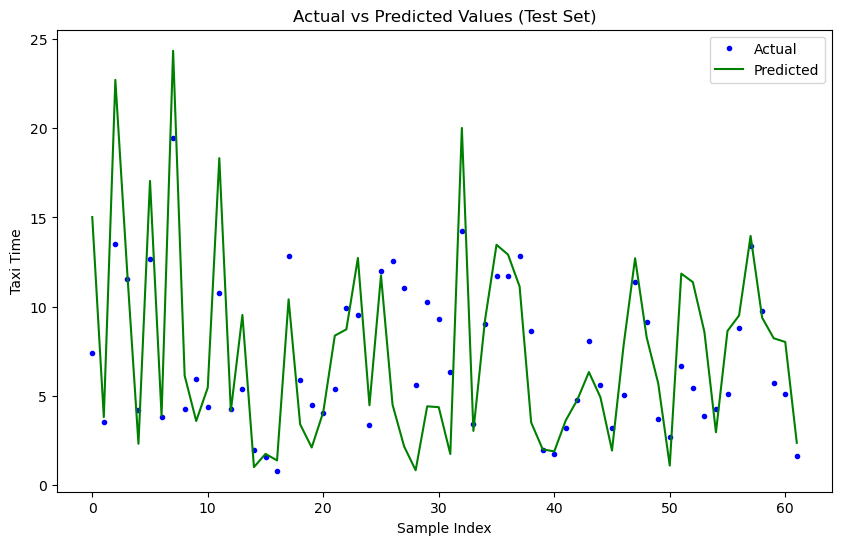

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.system('cls')  # On Windows System

# Random data generator
def random_number(a, b):
    return np.random.uniform(a, b)

# Leaky ReLU activation function
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

# Derivative of Leaky ReLU
def derived_leaky_relu(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)

# BP Neural Networks with three hidden layers
class BPNN:
    def __init__(self, num_in, num_hidden1, num_hidden2, num_hidden3, num_out):
        # Nodes of input, hidden, and output layers
        self.num_in = num_in + 1  # Add one bias node
        self.num_hidden1 = num_hidden1 + 1  # Add one bias node
        self.num_hidden2 = num_hidden2 + 1  # Add one bias node
        self.num_hidden3 = num_hidden3 + 1  # Add one bias node
        self.num_out = num_out

        # Activation nodes
        self.active_in = np.array([1.0] * self.num_in)
        self.active_hidden1 = np.array([1.0] * self.num_hidden1)
        self.active_hidden2 = np.array([1.0] * self.num_hidden2)
        self.active_hidden3 = np.array([1.0] * self.num_hidden3)
        self.active_out = np.array([1.0] * self.num_out)

        # Create weight matrices
        self.weight_in = random_number(-0.1, 0.1) * np.random.randn(self.num_in, self.num_hidden1 - 1)
        self.weight_hidden1 = random_number(-0.1, 0.1) * np.random.randn(self.num_hidden1, self.num_hidden2 - 1)
        self.weight_hidden2 = random_number(-0.1, 0.1) * np.random.randn(self.num_hidden2, self.num_hidden3 - 1)
        self.weight_out = random_number(-0.1, 0.1) * np.random.randn(self.num_hidden3, self.num_out)

    def Feedforward(self, inputs):
        # Input to first hidden layer
        self.active_in[1:self.num_in] = inputs
        self.sum_hidden1 = np.dot(self.weight_in.T, np.array([self.active_in]).T)
        self.active_hidden1 = np.vstack((1, leaky_relu(self.sum_hidden1)))

        # First hidden layer to second hidden layer
        self.sum_hidden2 = np.dot(self.weight_hidden1.T, self.active_hidden1)
        self.active_hidden2 = np.vstack((1, leaky_relu(self.sum_hidden2)))

        # Second hidden layer to third hidden layer
        self.sum_hidden3 = np.dot(self.weight_hidden2.T, self.active_hidden2)
        self.active_hidden3 = np.vstack((1, leaky_relu(self.sum_hidden3)))

        # Third hidden layer to output layer
        self.sum_out = np.dot(self.weight_out.T, self.active_hidden3)
        self.active_out = self.sum_out
        return self.active_out

    def errorbackpropagate(self, targets, lr):
        # Cost function
        self.error = (1 / 2) * np.dot((self.active_out - targets.T).T, (self.active_out - targets.T))
        self.gradient_out = self.active_out - targets.T
        self.gradient_w_out = np.dot(self.gradient_out, self.active_hidden3.T).T

        self.gradient_hidden3 = np.dot(self.weight_out[1:], self.gradient_out) * derived_leaky_relu(self.sum_hidden3)
        self.gradient_w_hidden2 = np.dot(self.gradient_hidden3, self.active_hidden2.T).T

        self.gradient_hidden2 = np.dot(self.weight_hidden2[1:], self.gradient_hidden3) * derived_leaky_relu(self.sum_hidden2)
        self.gradient_w_hidden1 = np.dot(self.gradient_hidden2, self.active_hidden1.T).T

        self.gradient_hidden1 = np.dot(self.weight_hidden1[1:], self.gradient_hidden2) * derived_leaky_relu(self.sum_hidden1)
        self.gradient_w_in = np.dot(self.gradient_hidden1, np.array([self.active_in])).T

        # Update weights
        self.weight_out -= lr * self.gradient_w_out
        self.weight_hidden2 -= lr * self.gradient_w_hidden2
        self.weight_hidden1 -= lr * self.gradient_w_hidden1
        self.weight_in -= lr * self.gradient_w_in
        return self.error

    def train(self, pattern, itera=2000, lr=0.01):
        for i in range(itera):
            error = 0
            for j in pattern:
                inputs = np.array([j[0:self.num_in - 1]])
                targets = np.array([j[self.num_in - 1:]])
                self.Feedforward(inputs)
                self.errorbackpropagate(targets, lr)
                error += self.error
            if i % 100 == 0:
                print(f"Iteration {i}, Error: {error[0][0]:.5f}")

    def test(self, patterns):
        Pre = []
        for i in patterns:
            inputs = np.array([i[0:self.num_in - 1]])
            Pre.append(self.Feedforward(inputs))
        return Pre

# Load and preprocess dataset as in your previous code
file_path = r'C:\Users\zuhay\Desktop\Machine learning Notebooks\Assignement\processed_dataset.CSV'
loaded_data = np.loadtxt(file_path, delimiter=',', skiprows=1)

X = loaded_data[:, :-1]
y = loaded_data[:, -1]

Q1 = np.percentile(y, 25)
Q3 = np.percentile(y, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outlier_indices = [i for i in range(len(y)) if lower_bound <= y[i] <= upper_bound]
X = X[non_outlier_indices]
y = y[non_outlier_indices]

X_mean, X_std = np.mean(X, axis=0), np.std(X, axis=0)
y_mean, y_std = np.mean(y), np.std(y)
X = (X - X_mean) / X_std
y = (y - y_mean) / y_std

split_train = int(0.7 * len(X))
split_val = int(0.85 * len(X))
X_train, y_train = X[:split_train], y[:split_train]
X_val, y_val = X[split_train:split_val], y[split_train:split_val]
X_test, y_test = X[split_val:], y[split_val:]

pattern = np.hstack((X_train, y_train.reshape(-1, 1)))

# Instantiate the network with three hidden layers
nn = BPNN(X_train.shape[1], 128, 64, 32, 1)
nn.train(pattern, itera=5000, lr=0.005)

test_patterns = np.hstack((X_test, y_test.reshape(-1, 1)))
predictions = nn.test(test_patterns)

y_pred = np.array([pred[0][0] for pred in predictions]) * y_std + y_mean
y_test_actual = y_test * y_std + y_mean

# Statistical Analysis
def compute_metrics(y_actual, y_pred):
    rmse = np.sqrt(np.mean((y_actual - y_pred) ** 2))
    mae = np.mean(np.abs(y_actual - y_pred))
    mre = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100
    return rmse, mae, mre

rmse, mae, mre = compute_metrics(y_test_actual, y_pred)
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, MRE: {mre:.2f}%")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_actual)), y_test_actual, 'b.', label='Actual')
plt.plot(range(len(y_pred)), y_pred, 'g-', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Values (Test Set)")
plt.xlabel("Sample Index")
plt.ylabel("Taxi Time")
plt.show()


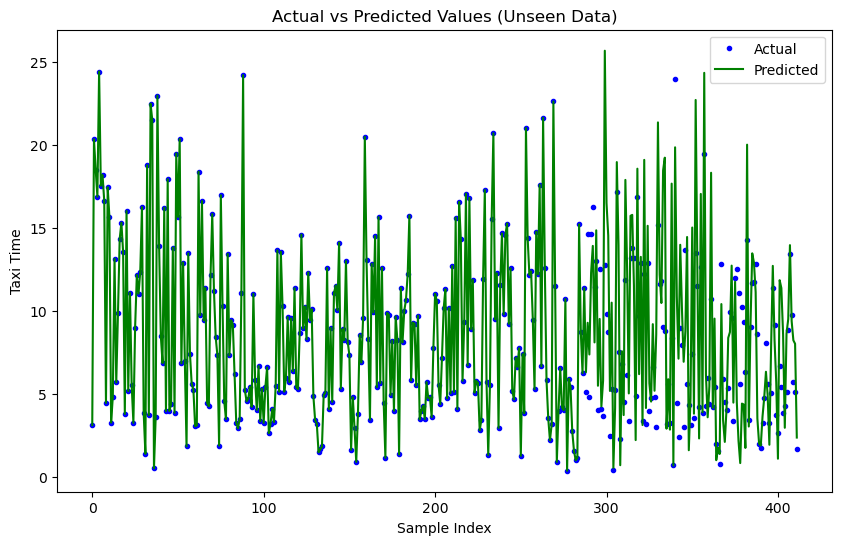

Unseen Data Results:
RMSE: 2.173
MAE: 0.879
MRE: 13.10%


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Load unseen data
unseen_file_path = r'C:\Users\zuhay\Desktop\Machine learning Notebooks\Assignement\processed_dataset.CSV'
unseen_data = np.loadtxt(unseen_file_path, delimiter=',', skiprows=1)

# Preprocess unseen data
X_unseen = unseen_data[:, :-1]
y_unseen = unseen_data[:, -1]

# Remove outliers using the IQR method
Q1 = np.percentile(y_unseen, 25)
Q3 = np.percentile(y_unseen, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

non_outlier_indices = [i for i in range(len(y_unseen)) if lower_bound <= y_unseen[i] <= upper_bound]
X_unseen = X_unseen[non_outlier_indices]
y_unseen = y_unseen[non_outlier_indices]

# Normalize unseen data using training normalization parameters
X_unseen = (X_unseen - X_mean) / X_std  # Use X_mean and X_std from training
y_unseen_actual = y_unseen  # Keep original for evaluation

# Test unseen data using the trained model
predictions = []
for x in X_unseen:
    predictions.append(nn.Feedforward(x))  # Use the trained model instance

# Denormalize predictions
y_pred_unseen = np.array([pred[0][0] for pred in predictions]) * y_std + y_mean

# Evaluate and visualize results
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_unseen_actual)), y_unseen_actual, 'b.', label='Actual')
plt.plot(range(len(y_pred_unseen)), y_pred_unseen, 'g-', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Values (Unseen Data)")
plt.xlabel("Sample Index")
plt.ylabel("Taxi Time")
plt.show()

# Compute metrics for unseen data
rmse_unseen = np.sqrt(np.mean((y_unseen_actual - y_pred_unseen) ** 2))
mae_unseen = np.mean(np.abs(y_unseen_actual - y_pred_unseen))
mre_unseen = np.mean(np.abs((y_unseen_actual - y_pred_unseen) / y_unseen_actual)) * 100

print(f"Unseen Data Results:")
print(f"RMSE: {rmse_unseen:.3f}")
print(f"MAE: {mae_unseen:.3f}")
print(f"MRE: {mre_unseen:.2f}%")



In [ ]:
import pandas as pd

# Create a DataFrame for Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_unseen_actual,
    "Predicted": y_pred_unseen
})

# Display the table in the console
print(results)

# Optionally save the DataFrame to a CSV file
results.to_csv("actual_vs_predicted.csv", index=False)
print("Results saved to 'actual_vs_predicted.csv'.")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_unseen_actual)), y_unseen_actual, 'b.', label='Actual')
plt.plot(range(len(y_pred_unseen)), y_pred_unseen, 'g-', label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Values (Unseen Data)")
plt.xlabel("Sample Index")
plt.ylabel("Taxi Time")
plt.show()

# Compute metrics for unseen data
rmse_unseen = np.sqrt(np.mean((y_unseen_actual - y_pred_unseen) ** 2))
mae_unseen = np.mean(np.abs(y_unseen_actual - y_pred_unseen))
mre_unseen = np.mean(np.abs((y_unseen_actual - y_pred_unseen) / y_unseen_actual)) * 100

print(f"Unseen Data Results:")
print(f"RMSE: {rmse_unseen:.3f}")
print(f"MAE: {mae_unseen:.3f}")
print(f"MRE: {mre_unseen:.2f}%")



NameError: name 'y_unseen_actual' is not defined